## Imports

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

---
## Fonction de simulation

In [10]:
def run_simulation(A, omega, E, rho, L, Nx, Nt, t_end, N, M):
    
    v = np.sqrt(E/rho)

    x  = np.linspace(0, L, Nx)
    dx = x[1] - x[0]
    dt = t_end / Nt

    CFL = v * dt / dx
    assert CFL <= 1.0, f"CFL={CFL:.3f} > 1 : schéma instable"

    
    t_pulse = 2 * np.pi / omega     #The period T

    def u_right(t): 
        if t < t_pulse:
            return A* np.sin(omega * t)
        else:
            return 0.0  

    u     = np.zeros(Nx)
    u_dot = np.zeros(Nx)
    u_2=np.zeros(Nx)

    u_storage         = np.zeros((Nt+1, Nx))
    u_dot_storage     = np.zeros((Nt, Nx))
    u_xx_storage      = np.zeros((Nt, Nx))
    delta_u_storage   = np.zeros((Nt, Nx))

    u_storage[0] = u.copy()

    # --- Boucle de simulation ---
    for n in range(Nt):
        tn = n * dt

        u_dot = np.zeros(Nx)
        u_xx = np.zeros(Nx)
        u_new = np.zeros(Nx)

        u_xx[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
        u_new[1:-1] = (2.0 * u[1:-1] - u_2[1:-1] + CFL**2 * (u[2:] - 2.0 * u[1:-1] + u[:-2]))
        u_dot[1:-1] = (u_new[1:-1] - u_2[1:-1]) / (2.0 * dt)

        u_new[0] = 0       
        u_dot[0] = 0          
        
        u_xx[-1] = (u[-3] - 2*u[-2] + u[-1]) / dx**2
        u_new[-1] = u_right(tn)
        u_dot[-1] = (u_new[-1] - u_2[-1]) / (2.0 * dt) 
        
        u_dot_storage[n]   = u_dot
        u_xx_storage[n]    = u_xx
        delta_u_storage[n] = u_new - u

        # Passage au pas de temps suivant
        u_2 = u.copy()
        u   = u_new
        u_storage[n+1] = u.copy()

    rows=[]

    def past_label(k):
        if k==0: return "@t"
        if k==1: return "@t-dt"
        return f"@t-{k}dt"

    # --- Construction du dataset ---
    for n in range(N-1, Nt-M+1):
        for j in range(1, Nx-1):
            row={"A":A,"omega":omega}

            #Inputs
            for k in range(N):
                row[f"u_dot{past_label(k)}"]=u_dot_storage[n-k,j]
                row[f"u_xx{past_label(k)}"]=u_xx_storage[n-k,j]

            #Outputs
            for k in range(M):
                row[f"delta_u@{k+1}dt"]=delta_u_storage[n+k,j]
            
            rows.append(row)
            

    return pd.DataFrame(rows), u_storage, x

## Génération du dataset complet

In [ ]:
all_dfs = []

#Parameters
E=1
rho=2
L=1

Nt=300
Nx=100
t_end=3

X=6

N=3    #Moments in the past + moment t
M=5    #Moments in the future

AMPLITUDES = np.linspace(0.005, 0.1, X).round(3).tolist()
PULSATIONS = np.linspace(7, 90, X).round(1).tolist()

n_sims=len(AMPLITUDES)*len(PULSATIONS)

# We compute each simulation
for idx, (A, w) in enumerate(product(AMPLITUDES, PULSATIONS), start=1):
    df_run,_,_ = run_simulation(A=A, omega=w, E=E,rho=rho, L=L, Nt=Nt, Nx=Nx, t_end=t_end, N=N, M=M)
    all_dfs.append(df_run)

# We concatenate each simulation in the df which is the full dataset table
df = pd.concat(all_dfs, ignore_index=True)
print(df.head(0))


Empty DataFrame
Columns: [A, omega, u_dot@t, u_xx@t, u_dot@t-dt, u_xx@t-dt, u_dot@t-2dt, u_xx@t-2dt, delta_u@1dt, delta_u@2dt, delta_u@3dt, delta_u@4dt, delta_u@5dt]
Index: []



## Split train / val / test

In [12]:
rng = np.random.default_rng(seed=42)

combos     = list(product(AMPLITUDES, PULSATIONS))
combos_arr = rng.permutation(combos)

n_train = int(0.70 * n_sims)
n_val   = int(0.15 * n_sims)

train_combos = set(map(tuple, combos_arr[:n_train]))
val_combos   = set(map(tuple, combos_arr[n_train:n_train + n_val]))
test_combos  = set(map(tuple, combos_arr[n_train + n_val:]))

def assign_split(row):
    key = (row["A"], row["omega"])
    if key in train_combos: return "train"
    if key in val_combos:   return "val"
    return "test"

df["split"] = df.apply(assign_split, axis=1)

print("Distribution du split :")
for s in ["train", "val", "test"]:
    n = (df["split"] == s).sum()
    print(f"  {s:5s} : {n:>8,} lignes  ({100*n/len(df):.1f} %)")


Distribution du split :
  train :  230,300 lignes  (69.4 %)
  val   :   46,060 lignes  (13.9 %)
  test  :   55,272 lignes  (16.7 %)


## Normalisation (z-score)

In [13]:
def past_label(k):
    if k ==0: return "@t"
    if k==1: return "@t-dt"
    return f"@t-{k}dt"

INPUTS  = ([f"u_dot{past_label(k)}"    for k in range(N)]
         + [f"u_xx{past_label(k)}" for k in range(N)])
OUTPUTS = [f"delta_u@{k+1}dt" for k in range(M)]

print("INPUTS  :", INPUTS)
print("OUTPUTS :", OUTPUTS)

# Masque train pour calculer les stats uniquement sur le train set
train_mask = df["split"] == "train"

# Calcul des stats sur le train set uniquement
norm_stats = pd.DataFrame({
    "mean": df.loc[train_mask, INPUTS + OUTPUTS].mean(),
    "std" : df.loc[train_mask, INPUTS + OUTPUTS].std(),
})
norm_stats["std"] = norm_stats["std"].replace(0, 1)  # éviter division par 0

# Application à tout le dataset
for col in INPUTS + OUTPUTS:
    df[col + "_n"] = (df[col] - norm_stats.loc[col, "mean"]) / norm_stats.loc[col, "std"]

print("Statistiques de normalisation (calculées sur train) :")
print(norm_stats.round(6))

INPUTS  : ['u_dot@t', 'u_dot@t-dt', 'u_dot@t-2dt', 'u_xx@t', 'u_xx@t-dt', 'u_xx@t-2dt']
OUTPUTS : ['delta_u@1dt', 'delta_u@2dt', 'delta_u@3dt', 'delta_u@4dt', 'delta_u@5dt']
Statistiques de normalisation (calculées sur train) :
                 mean        std
u_dot@t     -0.000013   0.527314
u_dot@t-dt  -0.000013   0.524249
u_dot@t-2dt -0.000013   0.521167
u_xx@t      -0.000014  84.574106
u_xx@t-dt   -0.000020  84.098484
u_xx@t-2dt   0.000027  83.620094
delta_u@1dt -0.000000   0.005698
delta_u@2dt -0.000001   0.005728
delta_u@3dt -0.000004   0.005754
delta_u@4dt -0.000007   0.005780
delta_u@5dt -0.000009   0.005801


---
## Sauvegarde

In [14]:
COLS_ORDER = (
    INPUTS                                   # inputs bruts
    + [c + "_n" for c in INPUTS]             # inputs normalisés
    + OUTPUTS                                # outputs bruts
    + [c + "_n" for c in OUTPUTS]            # outputs normalisés
    + ["split"]
)
df = df[COLS_ORDER]

# Dataset
df.to_csv("wave_beam_dataset.csv", index=False)
print(f"Dataset sauvegardé : wave_beam_dataset.csv")
print(f"  {len(df):,} lignes × {len(df.columns)} colonnes")

# Stats de normalisation — à recharger dans les fichiers 2 et 3
norm_stats.to_csv("norm_stats.csv")
print(f"Stats de normalisation sauvegardées : norm_stats.csv")

Dataset sauvegardé : wave_beam_dataset.csv
  331,632 lignes × 23 colonnes
Stats de normalisation sauvegardées : norm_stats.csv


In [15]:
import json

params_simulation = {
    "L": L, "Nx": Nx, "Nt": Nt, "t_end": t_end,
    "E": E, "rho": rho,
    "AMPLITUDES": AMPLITUDES, "PULSATIONS": PULSATIONS,
    "n_sims": n_sims,
    "N":N,
    "M":M,
    "INPUTS": INPUTS,
    "OUTPUTS": OUTPUTS,
}

with open("params_simulation.json", "w") as f:
    json.dump(params_simulation, f, indent=2)

print("Paramètres sauvegardés : params_simulation.json")

Paramètres sauvegardés : params_simulation.json


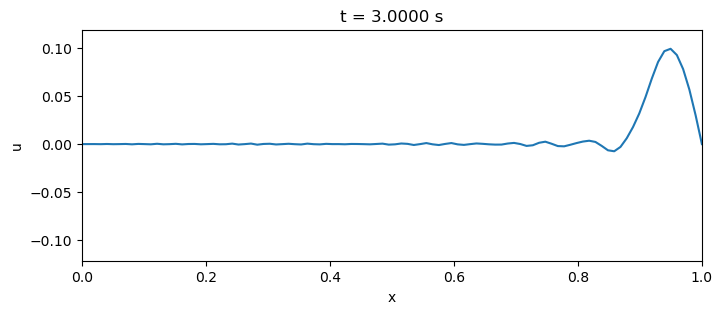

In [16]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Lance une simulation juste pour l'animation
A_demo, w_demo = 0.05, 20.0
_, u_storage, x = run_simulation(A_demo, w_demo, E, rho, L, Nx, Nt, t_end, N=1, M=1)

fig, ax = plt.subplots(figsize=(8, 3))
line, = ax.plot(x, u_storage[0])
ax.set_xlim(0, L)
ax.set_ylim(u_storage.min()*1.2, u_storage.max()*1.2)
ax.set_xlabel("x"); ax.set_ylabel("u")
title = ax.set_title("")

def update(n):
    line.set_ydata(u_storage[n])
    title.set_text(f"t = {n * t_end/Nt:.4f} s")
    return line, title

ani = FuncAnimation(fig, update, frames=range(0, Nt+1, 2), interval=30, blit=True)
HTML(ani.to_jshtml())